# Phase 6: Model Building

## Objective

The goal of this phase is to train multiple baseline machine learning models and compare their performance on the customer churn prediction task.

We will build:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

These models will serve as baseline models before hyperparameter tuning.

In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [3]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )

}

In [4]:
results = []

In [6]:
import joblib

data = joblib.load("../models/train_test_split.pkl")

X_train = data["X_train"]
X_test = data["X_test"]

y_train = data["y_train"]
y_test = data["y_test"]

In [ ]:
preprocessor = joblib.load("../models/preprocessor.pkl")

In [8]:
X_train_processed = preprocessor.transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [9]:
for name, model in models.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    # Train
    model.fit(X_train_processed, y_train)

    # Predict
    y_pred = model.predict(X_test_processed)

    # Probability predictions
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    print(classification_report(y_test, y_pred))

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC-AUC": roc_auc

    })

Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1035
           1       0.95      0.90      0.92       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409

Decision Tree
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1035
           1       0.91      0.89      0.90       374

    accuracy                           0.95      1409
   macro avg       0.93      0.93      0.93      1409
weighted avg       0.95      0.95      0.95      1409

Random Forest
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      1035
           1       0.94      0.80      0.87       374

    accuracy                           0.93      1409
   macro avg       0.94      0.89      0.91      1409
weighted avg       0.93   

In [10]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.960965,0.951841,0.898396,0.924347,0.991816
1,Decision Tree,0.946771,0.907357,0.890374,0.898785,0.928762
2,Random Forest,0.933996,0.943218,0.799465,0.865412,0.967550
3,XGBoost,0.963804,0.965418,0.895722,0.929265,0.991529


In [11]:
results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,XGBoost,0.963804,0.965418,0.895722,0.929265,0.991529
0,Logistic Regression,0.960965,0.951841,0.898396,0.924347,0.991816
1,Decision Tree,0.946771,0.907357,0.890374,0.898785,0.928762
2,Random Forest,0.933996,0.943218,0.799465,0.865412,0.967550


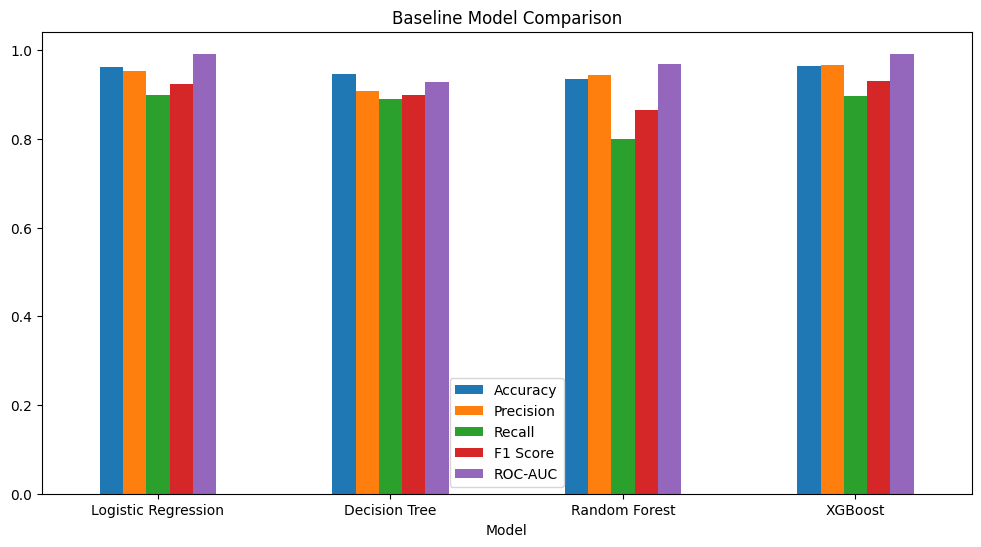

In [12]:
import matplotlib.pyplot as plt

results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    kind="bar",
    figsize=(12,6)
)

plt.xticks(rotation=0)

plt.title("Baseline Model Comparison")

plt.show()

In [13]:
best_model_name = results_df.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]["Model"]

print(best_model_name)

XGBoost


In [14]:
import joblib
best_model = models[best_model_name]

joblib.dump(
    best_model,
    "../models/best_baseline_model.pkl"
)

['../models/best_baseline_model.pkl']

# Summary

In this notebook we:

- Trained four baseline machine learning models.
- Compared their performance using multiple evaluation metrics.
- Selected the best-performing baseline model.
- Saved the best model for future optimization and deployment.

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1035
           1       0.97      0.90      0.93       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



## Model Selection

Among the baseline models, XGBoost achieved the highest F1 Score (0.9293) and an ROC-AUC of 0.9915. Since customer churn prediction is an imbalanced classification problem, F1 Score and ROC-AUC are more informative than accuracy alone.

Therefore, XGBoost was selected as the baseline model for further hyperparameter tuning and optimization.